In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data as Data
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# 加载数据
try:
    data_path = 'traffic-flow/traffic.npz'
    raw_data = np.load(data_path)['data']
except:
    # 模拟数据 (如果文件不存在)
    raw_data = np.random.randn(16992, 307, 3)

# 提取第0个节点的 [流量, 拥挤, 速度]
node_data = raw_data[:, 0, :] 

# 标准化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(node_data)

# 滑动窗口构建
def create_dataset(dataset, look_back=12):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back), :])
        dataY.append(dataset[i + look_back, 0]) # 预测流量
    return np.array(dataX), np.array(dataY)

SEQ_LEN = 12
X, y = create_dataset(scaled_data, SEQ_LEN)

# 划分数据集
train_size = int(len(X) * 0.8)
train_X = torch.from_numpy(X[:train_size]).type(torch.FloatTensor)
train_Y = torch.from_numpy(y[:train_size]).type(torch.FloatTensor)
test_X = torch.from_numpy(X[train_size:]).type(torch.FloatTensor).to(device) # 放入GPU加速测试
test_Y = torch.from_numpy(y[train_size:]).type(torch.FloatTensor) # CPU上的真实值

# DataLoader
train_loader = Data.DataLoader(
    Data.TensorDataset(train_X, train_Y), batch_size=64, shuffle=True
)

Running on: cuda


In [3]:
class TrafficRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(TrafficRNN, self).__init__()
        # 使用 torch.nn 封装的 RNN
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: (batch, seq, feature)
        # out: (batch, seq, hidden)
        out, h_n = self.rnn(x) 
        # 取最后一个时间步输出
        return self.fc(out[:, -1, :])
    
def calculate_metrics(y_true, y_pred):
    # 1. RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. MAE
    mae = mean_absolute_error(y_true, y_pred)
    
    # 3. MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if np.any(y_true != 0) else 0
    
    return mae, rmse, mape
    
def run_experiment(hidden_size, lr, epochs=15):
    """
    运行单次实验，记录训练集和测试集的 Loss, MAE, RMSE, MAPE, Time
    """
    # 1. 实例化模型
    model = TrafficRNN(input_dim=3, hidden_dim=hidden_size, output_dim=1).to(device)
    
    # 2. 定义优化器
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # 初始化历史记录
    history = {
        'train_loss': [], 'test_loss': [],
        'train_mae': [], 'test_mae': [],
        'train_rmse': [], 'test_rmse': [],
        'train_mape': [], 'test_mape': [],
        'time': []
    }
    
    # 3. 训练循环
    for epoch in range(epochs):
        epoch_start = time.time()
        
        # --- Train Stage ---
        model.train()
        train_loss_accum = 0
         
        train_preds = []
        train_trues = []
        
        for b_x, b_y in train_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            optimizer.zero_grad()
            output = model(b_x)
            loss = criterion(output.squeeze(), b_y)
            loss.backward()
            optimizer.step()
            
            train_loss_accum += loss.item()
            # 收集数据用于计算指标
            train_preds.append(output.squeeze().detach().cpu().numpy())
            train_trues.append(b_y.detach().cpu().numpy())
            
        avg_train_loss = train_loss_accum / len(train_loader)
        
        # 拼接 batch
        train_preds = np.concatenate(train_preds)
        train_trues = np.concatenate(train_trues)
        
        # 反标准化 (还原回真实流量)
        d_p = np.zeros((len(train_preds), 3)); d_p[:, 0] = train_preds
        inv_train_preds = scaler.inverse_transform(d_p)[:, 0]
        d_t = np.zeros((len(train_trues), 3)); d_t[:, 0] = train_trues
        inv_train_trues = scaler.inverse_transform(d_t)[:, 0]
        
        # 计算训练集的 MAE, RMSE, MAPE
        train_mae, train_rmse, train_mape = calculate_metrics(inv_train_trues, inv_train_preds)
        
        # --- Test Stage ---
        model.eval()
        with torch.no_grad():
            # 使用转换后的张量
            test_in = test_X # GPU tensor
            test_out = model(test_in)
              
            # Test Loss
            test_loss = criterion(test_out.squeeze(), test_Y.to(device)).item()
            
            # Test Metrics (反标准化)
            test_out_np = test_out.cpu().numpy()
            d_p_test = np.zeros((len(test_out_np), 3)); d_p_test[:, 0] = test_out_np.flatten()
            inv_test_preds = scaler.inverse_transform(d_p_test)[:, 0]
            
            d_t_test = np.zeros((len(test_Y), 3)); d_t_test[:, 0] = test_Y.numpy().flatten()
            inv_test_trues = scaler.inverse_transform(d_t_test)[:, 0]
            
            # 计算测试集的 MAE, RMSE, MAPE
            test_mae, test_rmse, test_mape = calculate_metrics(inv_test_trues, inv_test_preds)
        
        epoch_end = time.time()
        epoch_time = epoch_end - epoch_start
        
        # --- 记录数据 ---
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(test_loss)
        history['train_mae'].append(train_mae)
        history['test_mae'].append(test_mae)
        history['train_rmse'].append(train_rmse)
        history['test_rmse'].append(test_rmse)
        history['train_mape'].append(train_mape)
        history['test_mape'].append(test_mape)
        history['time'].append(epoch_time)
        
    return history

In [5]:
HIDDEN_LEVELS = [32, 64, 128]
FIXED_LR = 0.001
EPOCHS = 20

hidden_experiment_histories = {}

print("=== Experiment A: Effect of Hidden Size ===")
print(f"{'Hidden':^8} | {'RMSE':^10} | {'MAE':^10} | {'MAPE(%)':^10} | {'Time(s)':^8}")
print("-" * 70)

for h_dim in HIDDEN_LEVELS:

    history = run_experiment(
        hidden_size=h_dim,
        lr=FIXED_LR,
        epochs=EPOCHS
    )

    final_rmse = history['test_rmse'][-1]
    final_mae  = history['test_mae'][-1]
    final_mape = history['test_mape'][-1]
    avg_time   = np.mean(history['time'])

    hidden_experiment_histories[h_dim] = history

    print(f"{h_dim:^8} | "
          f"{final_rmse:^10.3f} | "
          f"{final_mae:^10.3f} | "
          f"{final_mape:^10.2f} | "
          f"{avg_time:^8.2f}")

=== Experiment A: Effect of Hidden Size ===
 Hidden  |    RMSE    |    MAE     |  MAPE(%)   | Time(s) 
----------------------------------------------------------------------
   32    |   28.736   |   21.209   |    7.83    |   1.52  
   64    |   28.669   |   21.147   |    7.73    |   1.39  
  128    |   29.554   |   21.873   |    8.10    |   1.43  


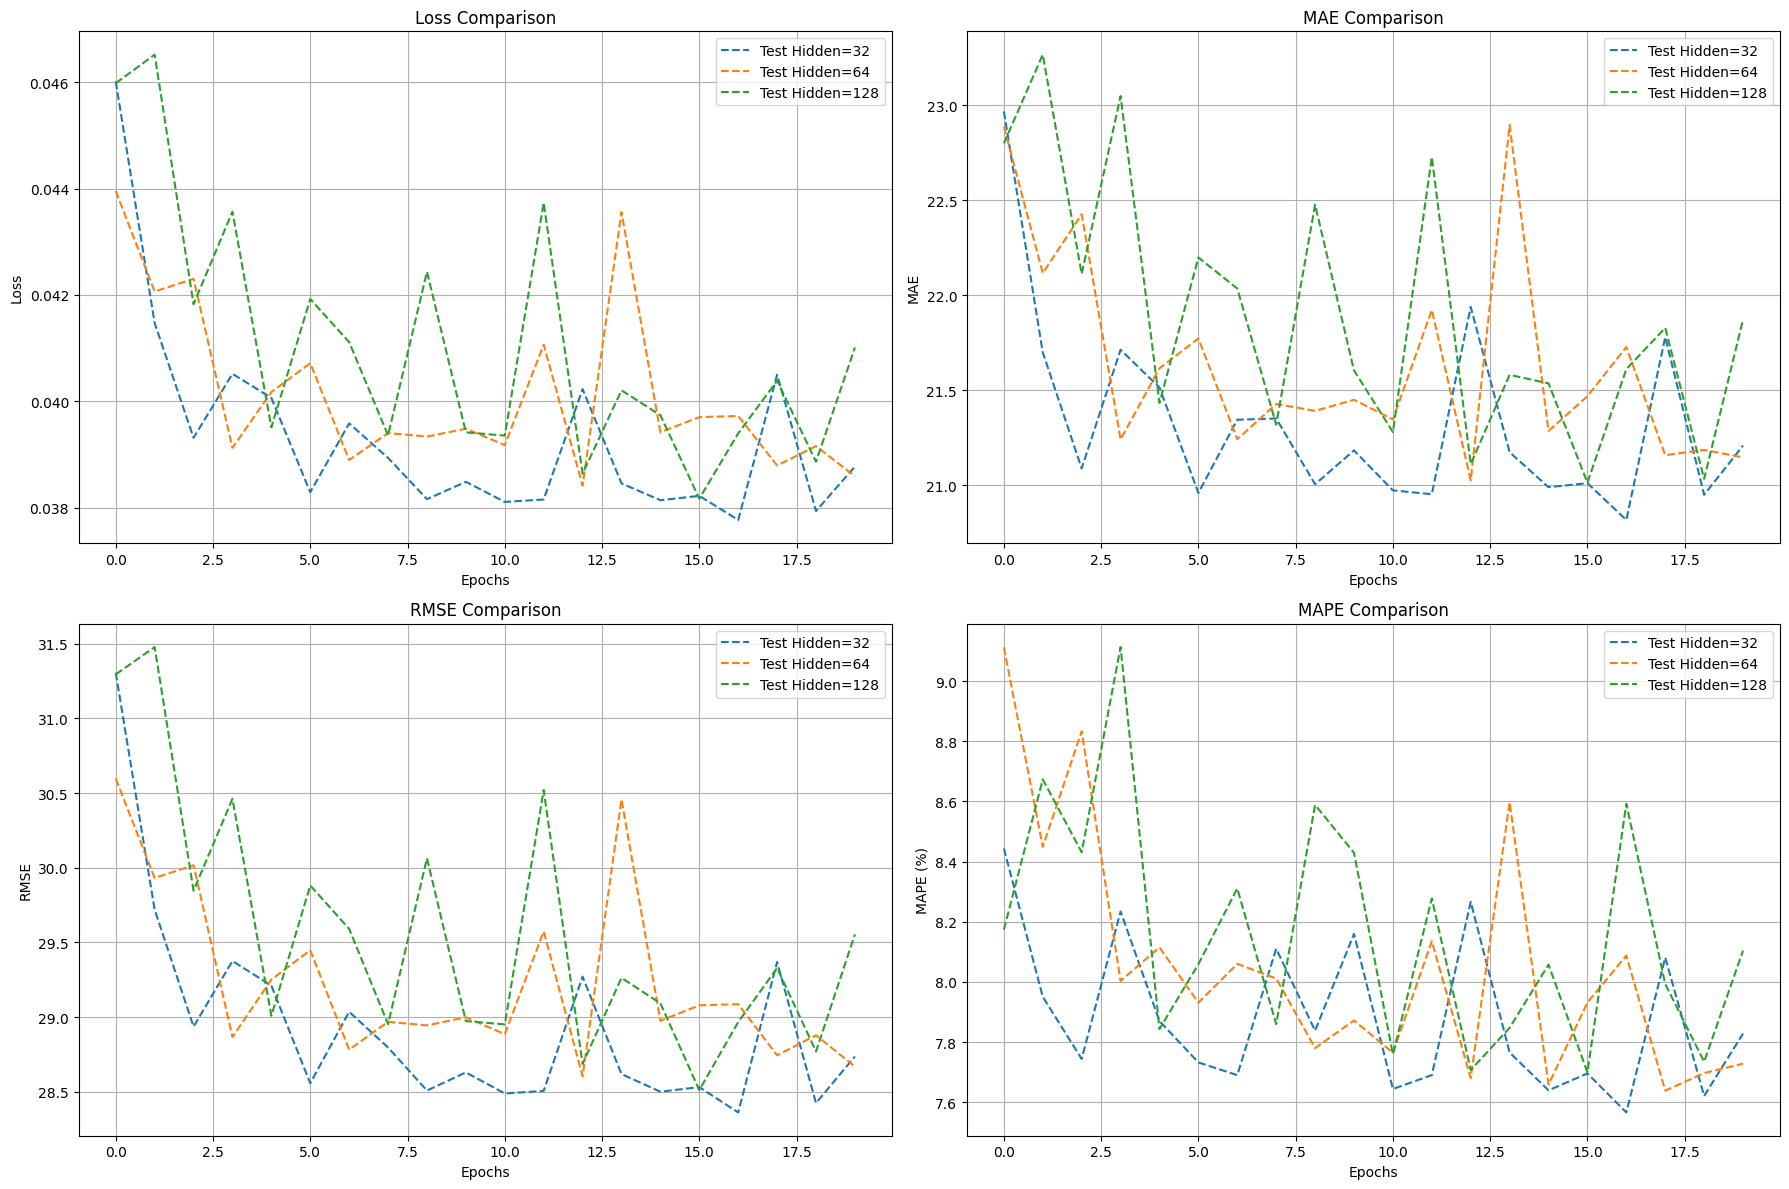

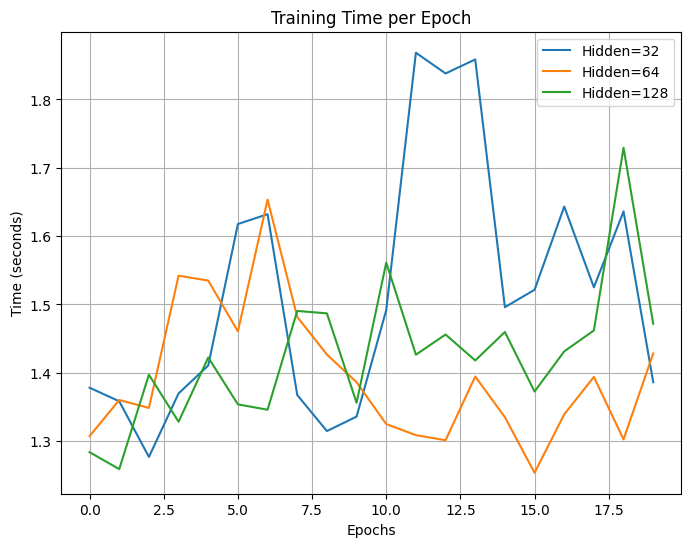

In [8]:
hiddens = list(hidden_experiment_histories.keys())

# 获取每个实验的历史数据
train_losses = {h: hidden_experiment_histories[h]['train_loss'] for h in hiddens}
test_losses = {h: hidden_experiment_histories[h]['test_loss'] for h in hiddens}

train_maes = {h: hidden_experiment_histories[h]['train_mae'] for h in hiddens}
test_maes = {h: hidden_experiment_histories[h]['test_mae'] for h in hiddens}

train_rmses = {h: hidden_experiment_histories[h]['train_rmse'] for h in hiddens}
test_rmses = {h: hidden_experiment_histories[h]['test_rmse'] for h in hiddens}

train_mapes = {h: hidden_experiment_histories[h]['train_mape'] for h in hiddens}
test_mapes = {h: hidden_experiment_histories[h]['test_mape'] for h in hiddens}

# 获取训练轮数
epochs_range = range(EPOCHS)

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
for h in hiddens:
    # plt.plot(epochs_range, train_losses[h], label=f"Train Hidden={h}")
    plt.plot(epochs_range, test_losses[h], label=f"Test Hidden={h}", linestyle='--')

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for h in hiddens:
    # plt.plot(epochs_range, train_maes[h], label=f"Train Hidden={h}")
    plt.plot(epochs_range, test_maes[h], label=f"Test Hidden={h}", linestyle='--')

plt.title("MAE Comparison")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
for h in hiddens:
    # plt.plot(epochs_range, train_rmses[h], label=f"Train Hidden={h}")
    plt.plot(epochs_range, test_rmses[h], label=f"Test Hidden={h}", linestyle='--')

plt.title("RMSE Comparison")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
for h in hiddens:
    # plt.plot(epochs_range, train_mapes[h], label=f"Train Hidden={h}")
    plt.plot(epochs_range, test_mapes[h], label=f"Test Hidden={h}", linestyle='--')

plt.title("MAPE Comparison")
plt.xlabel("Epochs")
plt.ylabel("MAPE (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 提取训练时间
train_times = {h: hidden_experiment_histories[h]['time'] for h in hiddens}

# 绘制训练时间
plt.figure(figsize=(8, 6))

for h in hiddens:
    plt.plot(epochs_range, train_times[h], label=f"Hidden={h}")

plt.title("Training Time per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()



In [6]:
LR_LEVELS = [0.01, 0.001, 0.0001]
FIXED_HIDDEN = 64
EPOCHS = 20

lr_experiment_histories = {}

print("\n=== Experiment B: Effect of Learning Rate ===")
print(f"{'LR':^8} | {'RMSE':^10} | {'MAE':^10} | {'MAPE(%)':^10} | {'Time(s)':^8}")
print("-" * 70)

for lr_val in LR_LEVELS:

    history = run_experiment(
        hidden_size=FIXED_HIDDEN,
        lr=lr_val,
        epochs=EPOCHS
    )

    final_rmse = history['test_rmse'][-1]
    final_mae  = history['test_mae'][-1]
    final_mape = history['test_mape'][-1]
    avg_time   = np.mean(history['time'])

    lr_experiment_histories[lr_val] = history

    print(f"{lr_val:^8} | "
          f"{final_rmse:^10.3f} | "
          f"{final_mae:^10.3f} | "
          f"{final_mape:^10.2f} | "
          f"{avg_time:^8.2f}")



=== Experiment B: Effect of Learning Rate ===
   LR    |    RMSE    |    MAE     |  MAPE(%)   | Time(s) 
----------------------------------------------------------------------
  0.01   |   41.570   |   34.455   |   16.25    |   1.48  
 0.001   |   28.859   |   21.402   |    8.14    |   1.42  
 0.0001  |   28.987   |   21.264   |    7.87    |   1.37  


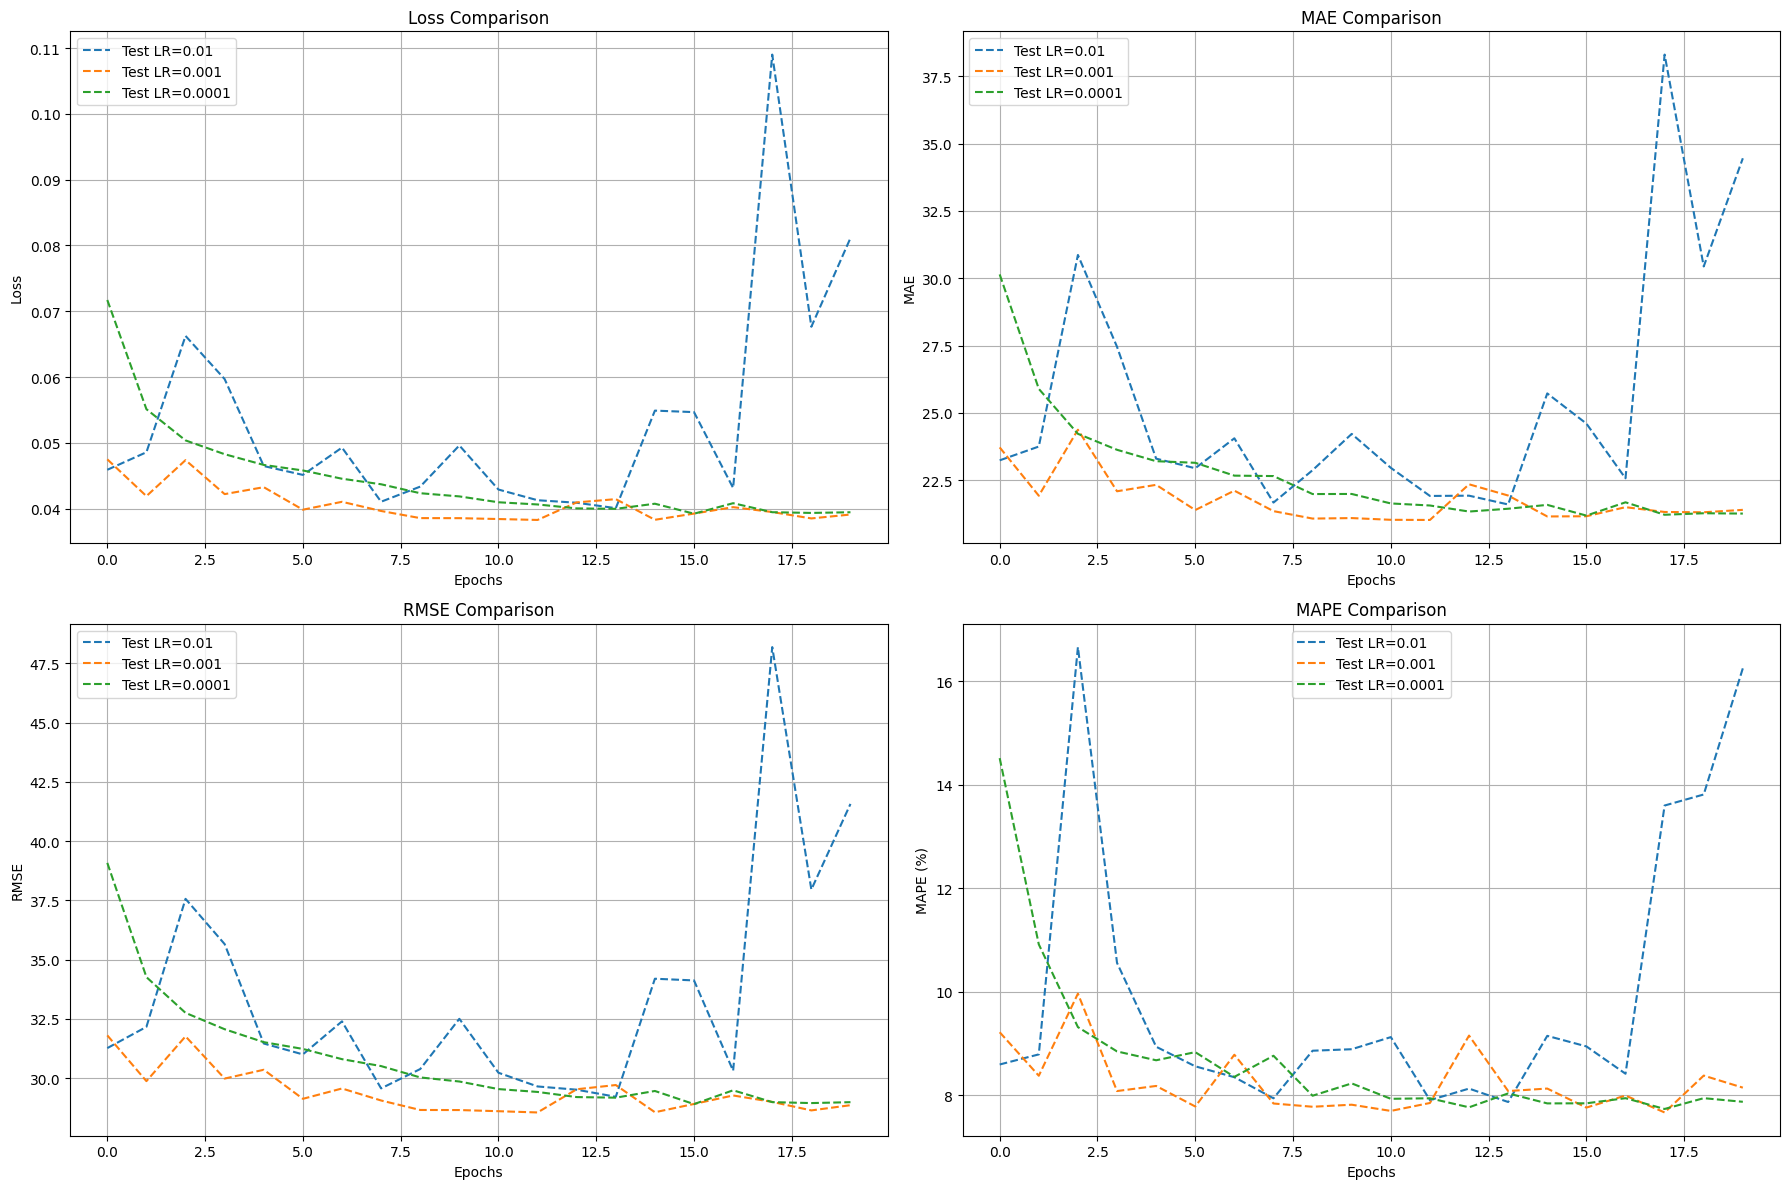

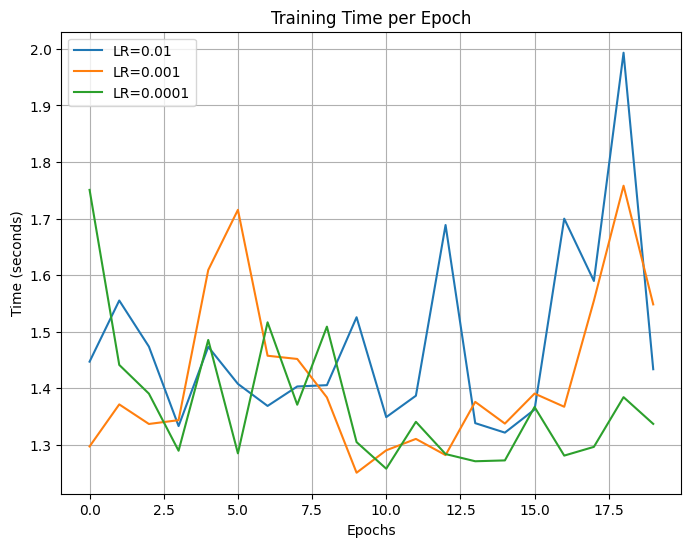

In [10]:
# 提取学习率实验数据
lrs = list(lr_experiment_histories.keys())

# 获取每个实验的历史数据
train_losses = {lr: lr_experiment_histories[lr]['train_loss'] for lr in lrs}
test_losses = {lr: lr_experiment_histories[lr]['test_loss'] for lr in lrs}

train_maes = {lr: lr_experiment_histories[lr]['train_mae'] for lr in lrs}
test_maes = {lr: lr_experiment_histories[lr]['test_mae'] for lr in lrs}

train_rmses = {lr: lr_experiment_histories[lr]['train_rmse'] for lr in lrs}
test_rmses = {lr: lr_experiment_histories[lr]['test_rmse'] for lr in lrs}

train_mapes = {lr: lr_experiment_histories[lr]['train_mape'] for lr in lrs}
test_mapes = {lr: lr_experiment_histories[lr]['test_mape'] for lr in lrs}

# 获取训练轮数
epochs_range = range(EPOCHS)

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
for lr in lrs:
    # plt.plot(epochs_range, train_losses[lr], label=f"Train LR={lr}")
    plt.plot(epochs_range, test_losses[lr], label=f"Test LR={lr}", linestyle='--')

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for lr in lrs:
    # plt.plot(epochs_range, train_maes[lr], label=f"Train LR={lr}")
    plt.plot(epochs_range, test_maes[lr], label=f"Test LR={lr}", linestyle='--')

plt.title("MAE Comparison")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
for lr in lrs:
    # plt.plot(epochs_range, train_rmses[lr], label=f"Train LR={lr}")
    plt.plot(epochs_range, test_rmses[lr], label=f"Test LR={lr}", linestyle='--')

plt.title("RMSE Comparison")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
for lr in lrs:
    # plt.plot(epochs_range, train_mapes[lr], label=f"Train LR={lr}")
    plt.plot(epochs_range, test_mapes[lr], label=f"Test LR={lr}", linestyle='--')

plt.title("MAPE Comparison")
plt.xlabel("Epochs")
plt.ylabel("MAPE (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 提取训练时间
train_times = {lr: lr_experiment_histories[lr]['time'] for lr in lrs}

# 绘制训练时间
plt.figure(figsize=(8, 6))

for lr in lrs:
    plt.plot(epochs_range, train_times[lr], label=f"LR={lr}")

plt.title("Training Time per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()
